# Feature Engineering: Encoding Substructures
Scenario: You are investigating toxicity and its dependency on molecular structure. Using the LD50 Toxicity dataset by Zhu (as provided here: https://huggingface.co/datasets/scikit-fingerprints/TDC_ld50_zhu/viewer), you calculate various molecular descriptors based on the SMILES and train a Random Forest Regressor to predict toxicity. You want to see if there is an improvement of the model when you take into account chemical structure - and generally, whether chemical structure is generally related to toxicity.

Note: the dataset is based on sparse chemical space and will not deliver super high prediction scores.

#### Tasks:
1) Load and inspect the dataset `tdc_ld50_zhu.csv`.
2) Feature engineering: Create a feature matrix `X_md` by calculating descriptors (full list as in rdkit) (Snippet provided)

3) Finding common substructures (functional groups, common scaffolds) is an alternative to detecting similarities based on fingerprints. Use the provided snippets to create different structure-based features and use one-hot encoding to make them more accessible also for other models.

4) Compare the prediction performance of the model for each of the feature matrices and combinations thereof:
- X_md: molecular descriptors only
- X_scaf: One-Hot-encoded Murcko scaffolds
- X_fg: One-hot-encoded functional groups
- X_md_scaf: Concatenation of X_md and X_scaf
- X_md_scaf_fg: Concatenation of X_md, X_scaf and X_fg

Note: For every different dataset you have to perform a train-test split and train the model before predicting. You do not need to use the suggested names!

5) Pick the best one and remove low-variance features (threshold 1%), as well as highly correlated ones (threshold 90%). See if the performance of the predictions by the model improves. Hint: Use `VarianceThreshold` (Unsupervised Algorithm from Scikit-learn) and `corr_matrix = X.corr().abs()` to do so (e.g. similarly as used in the Clustering example on the ESOL dataset)

6) Calculate Morgan Fingerprints (radius 2, 2048 bit) from the SMILES strings via mol objects. Make sure not to use the outdated version. You can use either the dataframe, numpy arrays or simple lists for the fingerprints.

7) Use Butina clustering on UMAP visualisation of the smiles-fingerprint space (scatterplot) and compare the plot side by side (e.g. as suplots) with a scatterplot colourmapped to the toxicity (look at options such as `colorbar` for matplotlib for better visualisation). 

8) Repeat 6 and 7 for the fingerprints based on the Murcko Scaffolds from task 3

9) Respond to the discussion points


Import dependencies and datasets

In [13]:
# complete imports if needed for your solution
import pandas as pd
import numpy as np

from rdkit import Chem
from rdkit.Chem import Descriptors
from rdkit.Chem import AllChem
from rdkit import DataStructs
from rdkit.Chem import rdFingerprintGenerator
from rdkit.Chem import MolFromSmarts
from rdkit.Chem.Scaffolds import MurckoScaffold

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
from sklearn.preprocessing import OneHotEncoder

from sklearn.manifold import TSNE
import umap

import matplotlib.pyplot as plt
import seaborn as sns

from rdkit.ML.Cluster import Butina

1) Load and investigate the data

In [25]:
tox = pd.read_csv("tdc_ld50_zhu.csv")
tox.head()

,smiles,ld_50
0,[O-][N+](=Nc1ccccc1)c1ccccc1,2.505
1,BrC(Br)Br,2.343
2,C=CBr,2.330
3,Brc1ccc(-c2ccc(Br)c(Br)c2Br)c(Br)c1Br,1.465
4,S=C=Nc1ccc(Br)cc1,2.729


In [26]:
tox.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7376 entries, 0 to 7375
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   smiles  7376 non-null   object 
 1   ld_50   7376 non-null   float64
dtypes: float64(1), object(1)
memory usage: 115.4+ KB


In [27]:
tox.describe()

,ld_50
count,7376.000000
mean,2.544235
std,0.959086
min,-0.343000
25%,1.855750
50%,2.367000
75%,3.035000
max,10.207000


2) Calculate descriptors

In [28]:
descriptor_names = [d[0] for d in Descriptors._descList]

def calc_descriptors(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None
    values = []
    for _, func in Descriptors._descList:
        try:
            values.append(func(mol))
        except:
            values.append(np.nan)
    return values

X_md = tox["smiles"].apply(calc_descriptors)
X_md = pd.DataFrame(X_md.tolist(), columns=descriptor_names, index=tox.index)

# keep only rows with valid descriptor values
valid_idx = X_md.dropna().index
X_md = X_md.loc[valid_idx].reset_index(drop=True)
y_md = tox.loc[valid_idx, "ld_50"].reset_index(drop=True)

X_md.head()

,MaxAbsEStateIndex,MaxEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,SPS,MolWt,HeavyAtomMolWt,ExactMolWt,NumValenceElectrons,...,fr_sulfide,fr_sulfonamd,fr_sulfone,fr_term_acetylene,fr_tetrazole,fr_thiazole,fr_thiocyan,fr_thiophene,fr_unbrch_alkane,fr_urea
0,11.564078,11.564078,0.529031,0.529031,0.412358,11.333333,198.225,188.145,198.079313,74,...,0,0,0,0,0,0,0,0,0,0
1,3.104167,3.104167,0.270833,0.270833,0.581278,9.000000,252.731,251.723,249.762836,26,...,0,0,0,0,0,0,0,0,0,0
2,3.277778,3.277778,1.562500,1.562500,0.439824,4.333333,106.950,103.926,105.941812,18,...,0,0,0,0,0,0,0,0,0,0
3,3.620234,3.620234,1.005501,1.005501,0.282041,10.777778,627.588,623.556,621.541323,94,...,0,0,0,0,0,0,0,0,0,0
4,4.438473,4.438473,0.831667,0.831667,0.516140,8.500000,214.087,210.055,212.924782,50,...,0,0,0,0,0,0,0,0,0,0


3) Find common scaffolds and encode them as binary vecotrs (one-hot-encoding). Note that the Scaffolds are represented as SMILES and can be used for fingerprints later

In [30]:
def get_scaffold(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None
    scaffold = MurckoScaffold.GetScaffoldForMol(mol)
    return Chem.MolToSmiles(scaffold)

tox["scaffold"] = tox["smiles"].apply(get_scaffold).astype(str)

OneHotEncoder for the Murcko scaffolds:

In [31]:
# one-hot encode scaffolds
# if your sklearn version complains about sparse_output, use sparse=False instead
encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)

X_scaf = encoder.fit_transform(tox[["scaffold"]])
scaffold_feature_names = encoder.get_feature_names_out(["scaffold"])

X_scaf = pd.DataFrame(X_scaf, columns=scaffold_feature_names, index=tox.index)
X_scaf.head()

,scaffold_,scaffold_C(#Cc1ccccc1)Cc1ccccc1,scaffold_C(=C(c1ccccc1)c1ccccc1)c1ccccc1,scaffold_C(=C1SCC(c2ccccc2)S1)n1ccnc1,scaffold_C(=CSSCC1CCCO1)NCc1cncnc1,scaffold_C(=Cc1ccccc1)C(C=Cc1ccccc1)=NN=C1NCCCN1,scaffold_C(=Cc1ccccc1)CN1CCN(c2cccnn2)CC1,scaffold_C(=Cc1ccccc1)c1ccccc1,scaffold_C(=Cc1ccco1)c1ccccn1,scaffold_C(=Cc1ccco1)c1ccco1,...,scaffold_c1ncn(C2CCCO2)n1,scaffold_c1ncnc(N(CCCCCCN(c2ncncn2)C2CCNCC2)C2CCNCC2)n1,scaffold_c1ncnc(NC2CC2)n1,scaffold_c1ncncn1,scaffold_c1ncsn1,scaffold_c1nnc(NCNc2nncs2)s1,scaffold_c1nnc[nH]1,scaffold_c1nnco1,scaffold_c1nncs1,scaffold_n1o[nH+]c2c1c1[nH+]onc1c1[nH+]onc21
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


Instead of structural scaffolds (via SMARTS), encode functional groups using the one-hot-encoder. Add some more functional groups that you think have impact on the toxicity of compounds.

In [32]:
functional_groups = {
    "amine": "[NX3;H2,H1;!$(NC=O)]",
    "carboxylic_acid": "C(=O)[OX2H1]",
    "aromatic_ring": "a",
    "alcohol": "[OX2H][CX4]",
    "phenol": "c[OX2H]",
    "amide": "C(=O)N",
    "ester": "C(=O)O[#6]",
    "ether": "[OD2]([#6])[#6]",
    "halogen": "[F,Cl,Br,I]",
    "nitro": "[$([NX3](=O)=O),$([N+](=O)[O-])]",
    "nitrile": "C#N",
    "sulfonamide": "S(=O)(=O)N",
    "thiol": "[#16X2H]",
    "thioether": "[#16X2][#6]",
    "alkene": "C=C",
    "alkyne": "C#C"
}

In [33]:
patterns = {k: Chem.MolFromSmarts(v) for k,v in functional_groups.items()}

def detect_groups(smiles):
    mol = Chem.MolFromSmiles(smiles)
    return {
        name: int(mol.HasSubstructMatch(pat))
        for name, pat in patterns.items()
    }

X_fg = pd.DataFrame(
    tox["smiles"].apply(detect_groups).tolist()
)

5) Pick the best one and prune the features regarding variance and correlation. Run the regression model again and compare the performance.

In [34]:
def evaluate_regression(X, y, name):
    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=0.3,
        random_state=42
    )

    model = RandomForestRegressor(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    )
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    r2 = r2_score(y_test, y_pred)
    print(f"{name}: R^2 = {r2:.3f}")
    return r2

In [35]:
results = {}

results["Descriptors"] = evaluate_regression(X_md, y_md, "Descriptors")
results["Scaffolds only"] = evaluate_regression(X_scaf, tox["ld_50"], "Scaffolds only")
results["Functional groups only"] = evaluate_regression(X_fg, tox["ld_50"], "Functional groups only")

# align scaffold and fg features to descriptor-valid rows for combinations
X_scaf_md = X_scaf.loc[valid_idx].reset_index(drop=True)
X_fg_md = X_fg.loc[valid_idx].reset_index(drop=True)

X_md_scaf = pd.concat([X_md, X_scaf_md], axis=1)
X_md_fg = pd.concat([X_md, X_fg_md], axis=1)
X_all = pd.concat([X_md, X_scaf_md, X_fg_md], axis=1)

results["Descriptors + scaffolds"] = evaluate_regression(X_md_scaf, y_md, "Descriptors + scaffolds")
results["Descriptors + functional groups"] = evaluate_regression(X_md_fg, y_md, "Descriptors + functional groups")
results["All combined"] = evaluate_regression(X_all, y_md, "All combined")

pd.Series(results).sort_values(ascending=False)

Descriptors: R^2 = 0.585
Scaffolds only: R^2 = 0.163
Functional groups only: R^2 = 0.244
Descriptors + scaffolds: R^2 = 0.584
Descriptors + functional groups: R^2 = 0.585
All combined: R^2 = 0.584


Descriptors                        0.584759
Descriptors + functional groups    0.584664
All combined                       0.584430
Descriptors + scaffolds            0.583672
Functional groups only             0.244055
Scaffolds only                     0.163245
dtype: float64

In [36]:
from sklearn.feature_selection import VarianceThreshold

# choose the best combined feature set
X_best = X_all.copy()

# 1) remove near-constant features
selector = VarianceThreshold(threshold=0.01)
X_var = selector.fit_transform(X_best)
kept_cols = X_best.columns[selector.get_support()]
X_var = pd.DataFrame(X_var, columns=kept_cols)

print("Before variance filtering:", X_best.shape)
print("After variance filtering:", X_var.shape)

# 2) remove highly correlated features
corr_matrix = X_var.corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

to_drop = [col for col in upper.columns if any(upper[col] > 0.95)]
X_pruned = X_var.drop(columns=to_drop)

print("After correlation filtering:", X_pruned.shape)
print("Dropped due to high correlation:", len(to_drop))

evaluate_regression(X_pruned, y_md, "Pruned feature set")

Before variance filtering: (7376, 1910)
After variance filtering: (7376, 212)
After correlation filtering: (7376, 182)
Dropped due to high correlation: 30
Pruned feature set: R^2 = 0.591


0.5911508433064075

6) Generate Morgan fingerprints (2048 bit, radius=2) for both "smiles" (entire molecules) and "scaffolds" (SMILES of common scaffolds only)

In [37]:
morgan_gen = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=2048)

# full-molecule fingerprints
mol_list = [Chem.MolFromSmiles(s) for s in tox["smiles"]]
fps_mol = [morgan_gen.GetFingerprint(mol) for mol in mol_list]

# scaffold fingerprints
scaffold_mols = []
for s in tox["scaffold"]:
    if s is None or s == "":
        scaffold_mols.append(Chem.MolFromSmiles(""))
    else:
        scaffold_mols.append(Chem.MolFromSmiles(s))

fps_scaf = [morgan_gen.GetFingerprint(mol) for mol in scaffold_mols]

print("Full molecule fingerprints:", len(fps_mol))
print("Scaffold fingerprints:", len(fps_scaf))

Full molecule fingerprints: 7376
Scaffold fingerprints: 7376


7) Butina clustering (as in last exercise): Experiment with different cutoffs and filter limits for the clusters (compare in the visualisation, no need to rerun the UMAP visualisation in between)

In [48]:
dists = []
nfps = len(fps_mol)
cutoff = 0.7

for i in range(1, nfps):
    sims = DataStructs.BulkTanimotoSimilarity(fps_mol[i], fps_mol[:i])
    dists.extend([1-x for x in sims])

clusters = Butina.ClusterData(
    dists,
    nfps,
    cutoff,
    isDistData=True
)

print("Number of clusters:", len(clusters))

Number of clusters: 1307


In [49]:
# filter out small clusters, rare chemoptypes, ...
clusters_filtered = [c for c in clusters if len(c) >= 5]

butina_labels = np.full(nfps, -1)
for cluster_id, cluster in enumerate(clusters_filtered):
    for id in cluster:
        butina_labels[id] = cluster_id

sizes = [len(c) for c in clusters_filtered]

print("clusters:", len(sizes))
print("mean size:", np.mean(sizes))
print("max size:", np.max(sizes))
print("singletons:", sum(s == 1 for s in sizes))

clusters: 302
mean size: 18.857615894039736
max size: 328
singletons: 0


Calculate UMAP space - play with `n_neighbors` and `min_distance` until you are satisfied with the visualisation.

In [50]:
# convert fingerprints to numpy
fp_array = np.zeros((nfps, 2048), dtype=int)
for i, fp in enumerate(fps_mol):
    DataStructs.ConvertToNumpyArray(fp, fp_array[i])

In [75]:
reducer = umap.UMAP(
    n_neighbors=10,
    min_dist=0.01,
    random_state=42
)

umap_emb = reducer.fit_transform(fp_array)

/Users/hugopeeters/DSA104/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Visualise the UMAP space with the a) the cluster labels and b) the toxicity as colour hue. (Incomplete snippet for matplotlib provided - feel free to use whatever visualisation that works best for you)

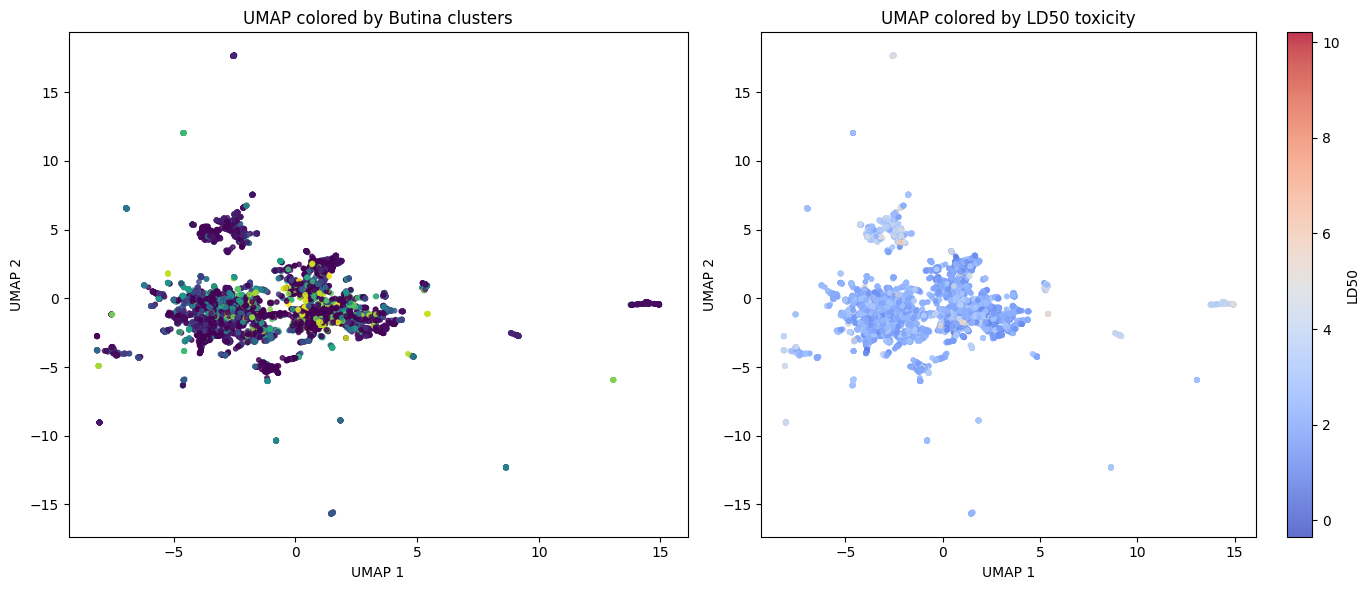

In [76]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# a) UMAP colored by cluster
sc1 = axes[0].scatter(
    umap_emb[:, 0],
    umap_emb[:, 1],
    c=butina_labels,
    cmap="viridis",
    s=10,
    alpha=0.8
)
axes[0].set_xlabel("UMAP 1")
axes[0].set_ylabel("UMAP 2")
axes[0].set_title("UMAP colored by Butina clusters")

# b) UMAP colored by toxicity
sc2 = axes[1].scatter(
    umap_emb[:, 0],
    umap_emb[:, 1],
    c=tox["ld_50"],
    cmap="coolwarm",
    s=10,
    alpha=0.8
)
axes[1].set_xlabel("UMAP 1")
axes[1].set_ylabel("UMAP 2")
axes[1].set_title("UMAP colored by LD50 toxicity")

cbar = plt.colorbar(sc2, ax=axes[1])
cbar.set_label("LD50")

plt.tight_layout()
plt.show()

In [77]:
dists = []
nfps = len(fps_scaf)
cutoff = 0.6

for i in range(1, nfps):
    sims = DataStructs.BulkTanimotoSimilarity(fps_scaf[i], fps_scaf[:i])
    dists.extend([1-x for x in sims])

clusters = Butina.ClusterData(
    dists,
    nfps,
    cutoff,
    isDistData=True
)

print("Number of clusters:", len(clusters))

Number of clusters: 747


In [78]:
# filter out small clusters, rare chemoptypes, ...
clusters_filtered = [c for c in clusters if len(c) >= 5]

butina_labels = np.full(nfps, -1)
for cluster_id, cluster in enumerate(clusters_filtered):
    for id in cluster:
        butina_labels[id] = cluster_id

sizes = [len(c) for c in clusters_filtered]

print("clusters:", len(sizes))
print("mean size:", np.mean(sizes))
print("max size:", np.max(sizes))
print("singletons:", sum(s == 1 for s in sizes))

clusters: 161
mean size: 40.27329192546584
max size: 1936
singletons: 0


In [79]:
# convert fingerprints to numpy
fp_array = np.zeros((nfps, 2048), dtype=int)
for i, fp in enumerate(fps_scaf):
    DataStructs.ConvertToNumpyArray(fp, fp_array[i])

In [86]:
reducer = umap.UMAP(
    n_neighbors=15,
    min_dist=0.5,
    random_state=42
)

umap_emb = reducer.fit_transform(fp_array)

/Users/hugopeeters/DSA104/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


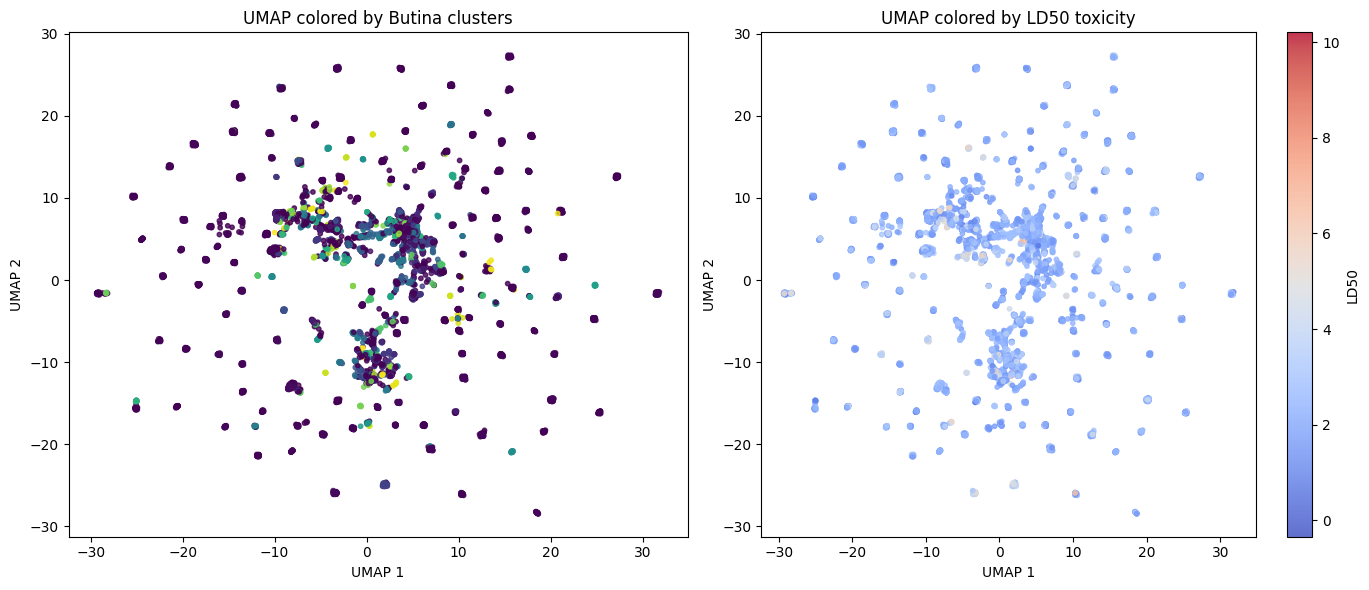

In [87]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# a) UMAP colored by cluster
sc1 = axes[0].scatter(
    umap_emb[:, 0],
    umap_emb[:, 1],
    c=butina_labels,
    cmap="viridis",
    s=10,
    alpha=0.8
)
axes[0].set_xlabel("UMAP 1")
axes[0].set_ylabel("UMAP 2")
axes[0].set_title("UMAP colored by Butina clusters")

# b) UMAP colored by toxicity
sc2 = axes[1].scatter(
    umap_emb[:, 0],
    umap_emb[:, 1],
    c=tox["ld_50"],
    cmap="coolwarm",
    s=10,
    alpha=0.8
)
axes[1].set_xlabel("UMAP 1")
axes[1].set_ylabel("UMAP 2")
axes[1].set_title("UMAP colored by LD50 toxicity")

cbar = plt.colorbar(sc2, ax=axes[1])
cbar.set_label("LD50")

plt.tight_layout()
plt.show()

#### 9) Discussion points
1) How did the scaffolds and functional groups perform in the model performance in comparison the molecular descriptors? Comment on possible reasons. Which combination was suited best?
- Descriptors performed significantly better than both the scaffolds and the functional groups. a possible reason is that there are so many descriptors and they contain almost all of the information about the molecules, including the functional groups.
2) Is the One-Hot Encoding needed in this case?
- Yes for the scaffolds because they are strings which cannot be processed by the model.
3) Did the feature filtering (variance, correlation) have an improving effect? Explain!
- only a little bit, because random forest is already robust to redundent features, so the filtering only improves it a little bit. But it likely does reduce the noise.
4) Consider to make this kind of workflow for feature comparison more generally usable: How would a clean solution look? How could you ensure compatibility with other models? How would the function / pipeline look schematically?
- a clean solution would have an automatic way of testing for optimal parameters. For making it compatible with other models, the feature generator should return a numeric matrix like a numpy array. This can then be used for random forest, linear models, XGBoost or neural networks. 
5) Visualisation: Using the scaffold fingerprints and the fingerprints for the entire molecule makes a huge difference. What is reason for this effect? Discuss this approach in contrast to similarity thresholds in the Butina clustering.
- the scaffolds only encode the core structure of the molecules, this makes a lot of the different molecules practically the same, and increasing overal similarity. 
6) When might scaffolding prove useful?
- when you want to group types of molecules together or when you want to simplify the data.
7) Is toxicity correlated to molecular structure? I.e. what did the toxicity map in UMAP space reveal?
- it seems like there is a correlation as some clusters can be seen with similar toxicity levels, but it is also clear that it is not just the molecular structure and that there is more to it.
